In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant"
)

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def gen_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {"joke" : response}

In [5]:
def gen_explanantion(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {"explanation" : response}

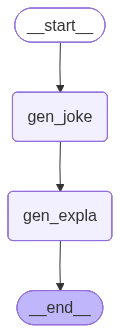

In [6]:
graph = StateGraph(JokeState)

graph.add_node("gen_joke", gen_joke)
graph.add_node("gen_expla", gen_explanantion)

graph.add_edge(START, "gen_joke")
graph.add_edge("gen_joke", "gen_expla")
graph.add_edge("gen_expla", END)

checkpointers = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointers)
workflow

In [7]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'BJP'}, config=config1)

{'topic': 'BJP',
 'joke': 'Why did the BJP leader bring a ladder to the meeting?\n\nBecause he wanted to take his agenda to the next level.',
 'explanation': 'The joke relies on a play on words. The phrase "take it to the next level" is a common idiom that means to raise something to a higher or more advanced position, often referring to achieving success or progress.\n\nIn this joke, the BJP leader is attending a meeting, and instead of bringing a traditional agenda or proposal, he brings a literal ladder. The punchline is that he wants to "take his agenda to the next level," which is a pun on the idiom.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, combined with the literal interpretation of the phrase as a demand for a ladder. The joke requires a basic understanding of the idiom and the ability to recognize the wordplay, which adds to its comedic effect.'}

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'BJP', 'joke': 'Why did the BJP leader bring a ladder to the meeting?\n\nBecause he wanted to take his agenda to the next level.', 'explanation': 'The joke relies on a play on words. The phrase "take it to the next level" is a common idiom that means to raise something to a higher or more advanced position, often referring to achieving success or progress.\n\nIn this joke, the BJP leader is attending a meeting, and instead of bringing a traditional agenda or proposal, he brings a literal ladder. The punchline is that he wants to "take his agenda to the next level," which is a pun on the idiom.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, combined with the literal interpretation of the phrase as a demand for a ladder. The joke requires a basic understanding of the idiom and the ability to recognize the wordplay, which adds to its comedic effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'BJP', 'joke': 'Why did the BJP leader bring a ladder to the meeting?\n\nBecause he wanted to take his agenda to the next level.', 'explanation': 'The joke relies on a play on words. The phrase "take it to the next level" is a common idiom that means to raise something to a higher or more advanced position, often referring to achieving success or progress.\n\nIn this joke, the BJP leader is attending a meeting, and instead of bringing a traditional agenda or proposal, he brings a literal ladder. The punchline is that he wants to "take his agenda to the next level," which is a pun on the idiom.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, combined with the literal interpretation of the phrase as a demand for a ladder. The joke requires a basic understanding of the idiom and the ability to recognize the wordplay, which adds to its comedic effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '',

In [10]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'congress indian political party'}, config=config2)

{'topic': 'congress indian political party',
 'joke': "Here's a joke:\n\nWhy did the Congress and BJP go to therapy together?\n\nBecause the Congress was struggling with 'Dynasty' issues, and the BJP was having trouble 'Modi-fying' their image, but in the end, they decided to 'Merge' their problems and work on a 'United Front'! (Note: This is a lighthearted joke and not meant to be taken seriously or to offend any political party or group.)",
 'explanation': "This joke is a play on words that incorporates elements of Indian politics and puns. Here's a breakdown of the joke:\n\n1. **Dynasty issues**: This refers to the Congress party's historical tendency to have family members holding prominent positions within the party. The Gandhi family, particularly Nehru and Indira Gandhi, have played significant roles in the party's leadership. The joke is poking fun at this dynastic tradition.\n\n2. **Modi-fying**: This is a pun on the name of the BJP's (Bharatiya Janata Party) prominent leader,

In [11]:

workflow.get_state(config2)

StateSnapshot(values={'topic': 'congress indian political party', 'joke': "Here's a joke:\n\nWhy did the Congress and BJP go to therapy together?\n\nBecause the Congress was struggling with 'Dynasty' issues, and the BJP was having trouble 'Modi-fying' their image, but in the end, they decided to 'Merge' their problems and work on a 'United Front'! (Note: This is a lighthearted joke and not meant to be taken seriously or to offend any political party or group.)", 'explanation': "This joke is a play on words that incorporates elements of Indian politics and puns. Here's a breakdown of the joke:\n\n1. **Dynasty issues**: This refers to the Congress party's historical tendency to have family members holding prominent positions within the party. The Gandhi family, particularly Nehru and Indira Gandhi, have played significant roles in the party's leadership. The joke is poking fun at this dynastic tradition.\n\n2. **Modi-fying**: This is a pun on the name of the BJP's (Bharatiya Janata Party

In [12]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'congress indian political party', 'joke': "Here's a joke:\n\nWhy did the Congress and BJP go to therapy together?\n\nBecause the Congress was struggling with 'Dynasty' issues, and the BJP was having trouble 'Modi-fying' their image, but in the end, they decided to 'Merge' their problems and work on a 'United Front'! (Note: This is a lighthearted joke and not meant to be taken seriously or to offend any political party or group.)", 'explanation': "This joke is a play on words that incorporates elements of Indian politics and puns. Here's a breakdown of the joke:\n\n1. **Dynasty issues**: This refers to the Congress party's historical tendency to have family members holding prominent positions within the party. The Gandhi family, particularly Nehru and Indira Gandhi, have played significant roles in the party's leadership. The joke is poking fun at this dynastic tradition.\n\n2. **Modi-fying**: This is a pun on the name of the BJP's (Bharatiya Janata Part

## Time Travel in LangGraph

In [13]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f160c55-23ce-64b2-bfff-0884a72bcd92"}})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f160c55-23ce-64b2-bfff-0884a72bcd92'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-06-05T10:00:02.974211+00:00', parent_config=None, tasks=(PregelTask(id='3d286788-aa94-b022-d268-f0656783402c', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'BJP'}),), interrupts=())

In [14]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f160c55-23ce-64b2-bfff-0884a72bcd92"}})

{'topic': 'BJP',
 'joke': "Here's a joke:\n\nWhy did the BJP leader bring a ladder to the meeting?\n\nBecause he wanted to take his governance to the next level, but it turned out to be a tall order!\n\n(Note: This joke is in good humor and not intended to offend any political party or its supporters.",
 'explanation': 'This joke is a play on words, using a common phrase associated with politics in a clever and humorous way. The phrase "take it to the next level" is often used in the context of governance or politics, implying that one wants to improve or elevate their policies or performance.\n\nIn this joke, the BJP leader brings a literal ladder to the meeting, which initially hints at a desire to literally elevate or ascend to a higher level of governance. However, the punchline "but it turned out to be a tall order" is a wordplay on two meanings:\n\n1. The joke implies that the leader\'s goal of elevating governance was ambitious and difficult to achieve, but the phrase "tall orde

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'BJP', 'joke': "Here's a joke:\n\nWhy did the BJP leader bring a ladder to the meeting?\n\nBecause he wanted to take his governance to the next level, but it turned out to be a tall order!\n\n(Note: This joke is in good humor and not intended to offend any political party or its supporters.", 'explanation': 'This joke is a play on words, using a common phrase associated with politics in a clever and humorous way. The phrase "take it to the next level" is often used in the context of governance or politics, implying that one wants to improve or elevate their policies or performance.\n\nIn this joke, the BJP leader brings a literal ladder to the meeting, which initially hints at a desire to literally elevate or ascend to a higher level of governance. However, the punchline "but it turned out to be a tall order" is a wordplay on two meanings:\n\n1. The joke implies that the leader\'s goal of elevating governance was ambitious and difficult to achieve, but t

## Update State

In [16]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f160c55-23ce-64b2-bfff-0884a72bcd92", "checkpoint_ns": ""}}, {'topic':'AAM Adami Party'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f160c6c-4e3c-62e2-8000-ec0b19559075'}}

In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AAM Adami Party'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f160c6c-4e3c-62e2-8000-ec0b19559075'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-05T10:10:24.824782+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f160c55-23ce-64b2-bfff-0884a72bcd92'}}, tasks=(PregelTask(id='9b262759-7bb8-8a0d-bd9a-3e5de3a1e2e3', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'BJP', 'joke': "Here's a joke:\n\nWhy did the BJP leader bring a ladder to the meeting?\n\nBecause he wanted to take his governance to the next level, but it turned out to be a tall order!\n\n(Note: This joke is in good humor and not intended to offend any political party or its supporters.", 'explanation': 'This joke is a play on words, using a common

In [18]:
len(list(workflow.get_state_history(config1)))

9

In [19]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f160c6c-4e3c-62e2-8000-ec0b19559075"}})

{'topic': 'AAM Adami Party',
 'joke': 'Why did the AAM Adami activist bring a ladder to the protest?\n\nBecause they wanted to take their demands to a higher level.',
 'explanation': 'This joke is a play on words, using a pun to create humor. Here\'s a breakdown of the explanation:\n\nThe joke starts with the setup: an AAM Adami activist brings a ladder to a protest. AAM Adami is a reference to a political party in Bangladesh, but in this context, it\'s just a red herring to add a layer of complexity. \n\nThe punchline "they wanted to take their demands to a higher level" has a double meaning:\n\n1. In a literal sense, a ladder allows people to reach higher places, so the activist is using the ladder to literally take their demands to a higher level.\n\n2. In a figurative sense, "taking it to a higher level" is an idiomatic expression that means to raise the stakes, escalate the issue, or make it more pressing. In this context, the joke is saying that the activist wants to make their d

In [20]:
len(list(workflow.get_state_history(config1)))

11

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AAM Adami Party', 'joke': 'Why did the AAM Adami activist bring a ladder to the protest?\n\nBecause they wanted to take their demands to a higher level.', 'explanation': 'This joke is a play on words, using a pun to create humor. Here\'s a breakdown of the explanation:\n\nThe joke starts with the setup: an AAM Adami activist brings a ladder to a protest. AAM Adami is a reference to a political party in Bangladesh, but in this context, it\'s just a red herring to add a layer of complexity. \n\nThe punchline "they wanted to take their demands to a higher level" has a double meaning:\n\n1. In a literal sense, a ladder allows people to reach higher places, so the activist is using the ladder to literally take their demands to a higher level.\n\n2. In a figurative sense, "taking it to a higher level" is an idiomatic expression that means to raise the stakes, escalate the issue, or make it more pressing. In this context, the joke is saying that the activist w